#  Exercise 7 The resource-consumer NP model with odeint

**Claude AI was used to create model here**: 

    "def npd_model(y, t, mu, m, r):

    N, P, D = y

    dNdt = -mu*N*P + r*D
    dPdt = mu*N*P - m*P
    dDdt = m*P - r*D

    return [dNdt, dPdt, dDdt]
"

The rest is recycled code. 

In [17]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [18]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [19]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

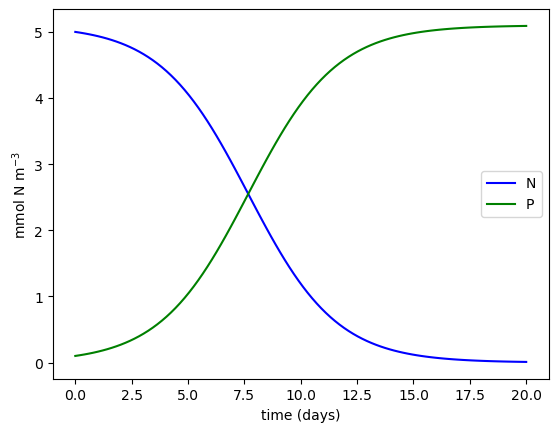

In [20]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise 7
2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

dt/dN =−μNP+r
dP/dt =μNP−mP
dD/dt =mP−rD

# initial conditions
K = 0.1
N0 = 10
P0 = 0.1
gr = 0.1
mr = 0.05
D0 = 0.0

y0 = [N0, P0, D0]

t = np.linspace(0, 50, 100)

def model(y, t, rg, m, r):


In [21]:
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

The function model takes the current variable (y), time(t) and the model parameters as inputs. The state variables are usually stored in a list or a NumPy array, while time is a float. The output is a list or NumPy array containing the derivates of the state variables, which are used by the odient solver to calculate the numerical solution. 

Growth (mu)(μ=0.5) faster than mortality (m=0.1) faster than remineralisation (r=0.05), so phytoplankton bloom first, then die, and detritus recycles slowly back to nutrient.

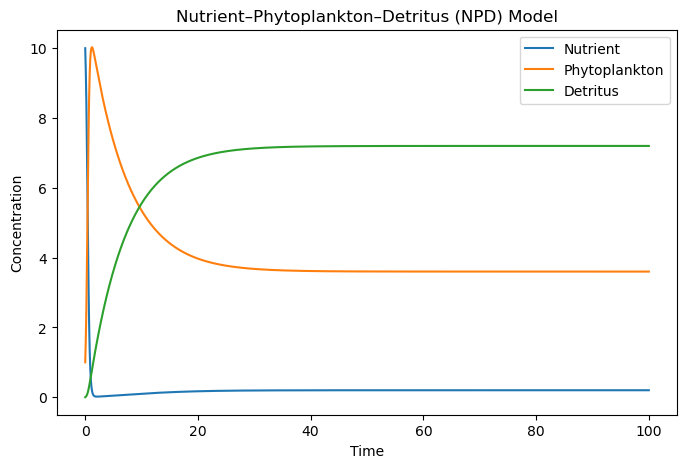

In [23]:

def npd_model(y, t, mu, m, r):

    N, P, D = y

    dNdt = -mu*N*P + r*D
    dPdt = mu*N*P - m*P
    dDdt = m*P - r*D

    return [dNdt, dPdt, dDdt]

# Parameter values
mu = 0.5      # phytoplankton growth rate
m = 0.1       # mortality rate
r = 0.05      # remineralization rate

# Initial conditions
N0 = 10.0
P0 = 1.0
D0 = 0.0

y0 = [N0, P0, D0]

# Time vector
t = np.linspace(0, 100, 1000)

# Solve
sol = odeint(npd_model, y0, t, args=(mu, m, r))

# Extract variables
N = sol[:,0]
P = sol[:,1]
D = sol[:,2]

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, N, label='Nutrient')
plt.plot(t, P, label='Phytoplankton')
plt.plot(t, D, label='Detritus')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Nutrient–Phytoplankton–Detritus (NPD) Model')
plt.legend()
plt.show()

**Figure 2: Nutrient-Phytoplankton-Detritus model simulated concentrations.**

Nutrients decreasing intially as phytoplankton grows, the population then stabilises and detritus begins accumulating from phytoplankton mortality. 